In [2]:
# imports

from data_processing import df_to_markov, csv_to_dfs
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
# from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

### Data Processing
All of the important data processing tools can be found in data_processing.py

This code takes a list of social isolation data and converts it to a Markov Chain adjacency matrix

In [3]:
df_list = csv_to_dfs("/Users/anu/Documents/carleton/fly_syntax_nlp/SocialIsolationData.csv")
    
syntax_list = [df_to_markov(df) for df in df_list]
frequency_list = [df_to_markov(df, counts=True) for df in df_list]
genotype_list = [df['genotype'].tolist()[0] for df in df_list]

print(syntax_list)
print(genotype_list)

[               head  abdominal  wing   rubbing  thorax
head       1.000000        0.0   0.0  0.000000     0.0
abdominal  0.000000        0.0   0.0  0.000000     0.0
wing       0.000000        0.0   0.0  1.000000     0.0
rubbing    0.055556        0.0   0.0  0.944444     0.0
thorax     0.000000        0.0   0.0  0.000000     0.0,                head  abdominal  wing   rubbing  thorax
head       1.000000        0.0   0.0  0.000000     0.0
abdominal  0.000000        0.0   0.0  0.000000     0.0
wing       0.000000        0.0   0.5  0.500000     0.0
rubbing    0.033333        0.0   0.0  0.966667     0.0
thorax     0.000000        0.0   0.0  0.000000     0.0,                head  abdominal  wing   rubbing  thorax
head       1.000000        0.0   0.0  0.000000     0.0
abdominal  0.000000        0.0   0.0  0.000000     0.0
wing       0.000000        0.0   0.5  0.500000     0.0
rubbing    0.017241        0.0   0.0  0.982759     0.0
thorax     0.000000        0.0   0.0  0.000000     0.0,       

/Users/anu/Documents/carleton/fly_syntax_nlp/data_processing.py:26: RuntimeWarning: invalid value encountered in divide
  probabilities = (frequencies.values)/normalizing


### Embedding

In [4]:
embedder = TSNE(
    n_components=2,
    init="random",
    max_iter=250,
    random_state=1,
)

# embedder = PCA(
#     n_components=2
# )

X = [np.reshape(df.values, 25) for df in syntax_list]
X_f = [np.reshape(df.values, 25) for df in frequency_list]

reduced_syntax = embedder.fit_transform(np.array(X))

<Axes: >

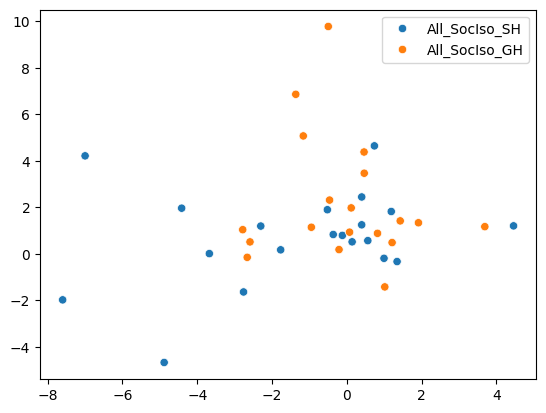

In [20]:
sns.scatterplot(x=reduced_syntax[:, 0], y=reduced_syntax[:, 1], hue=genotype_list)

In [24]:
plot_df = pd.DataFrame(X)
plot_df['genotype'] = genotype_list

In [39]:
plot_df.groupby('genotype').mean().reset_index()

,genotype,0,1,2,3,4,5,6,7,8,...,15,16,17,18,19,20,21,22,23,24
0,All_SocIso_GH,0.77867,0.063435,0.0,0.0,0.0,0.0,0.842105,0.0,0.0,...,0.026185,0.003848,0.0,0.969967,0.0,0.0,0.0,0.0,0.276316,0.144737
1,All_SocIso_SH,0.86696,0.133040,0.0,0.0,0.0,0.0,0.500000,0.0,0.0,...,0.031950,0.000000,0.0,0.968050,0.0,0.0,0.0,0.0,0.012500,0.037500


<Axes: xlabel='variable', ylabel='value'>

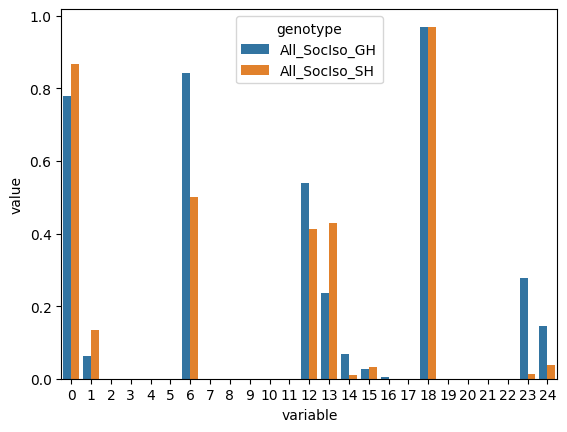

In [44]:
sns.barplot(x = "variable", y = "value", hue="genotype", data=pd.melt(plot_df.groupby('genotype').mean().reset_index(), id_vars="genotype"))

In [8]:
df = pd.read_csv("SocialIsolationData.csv")
df = df.query("behavior != 'class_all_grooming'")